In [8]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astromodels import PointSource, Model, Powerlaw, Gaussian
from threeML import DataList, BayesianAnalysis, Log_uniform_prior, Uniform_prior
from threeML import XYLike
from aperture_test import AperturePlugin

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
rng = np.random.default_rng(42)

x = np.linspace(1, 10, 30)
sigma = 0.05

# Dataset 1: pure power law
pl_true = 10 * x**(-1.5)
y1 = pl_true + rng.normal(0, sigma * pl_true)
dy1 = sigma * pl_true

# Dataset 2: power law + Gaussian bump
gauss_true = 3 * np.exp(-0.5 * ((x - 5.0) / 0.4)**2)
y2 = pl_true + gauss_true + rng.normal(0, sigma * (pl_true + gauss_true))
dy2 = sigma * (pl_true + gauss_true)

data1 = XYLike("data1", x, y1, dy1)
data2 = XYLike("data2", x, y2, dy2)

In [3]:
# Shared power law — one instance per source
pl1 = Powerlaw()
pl1.K = 10.0
pl1.index = -1.5
pl1.K.bounds = (1e-2, 1e2)
pl1.index.bounds = (-3.0, 0.0)
pl1.K.prior = Log_uniform_prior(lower_bound=1e-2, upper_bound=1e2)
pl1.index.prior  = Uniform_prior(lower_bound=-3, upper_bound=0.0)

# pl2 = Powerlaw()
# pl2.K = 10.0
# pl2.index = -1.5
# pl2.K.bounds = (1e-2, 1e2)
# pl2.index.bounds = (-3.0, 0.0)

g = Gaussian()
g.F = 0.5
g.mu = 5.0
g.sigma = 0.4
g.F.bounds = (1e-3, 5.0)
g.mu.bounds = (2.0, 8.0)
g.sigma.bounds = (0.1, 2.0)
g.F.prior  = Log_uniform_prior(lower_bound=1e-3, upper_bound=5)
g.mu.prior  = Uniform_prior(lower_bound=2, upper_bound=8)
g.sigma.prior  = Log_uniform_prior(lower_bound=1e-1, upper_bound=2)

src1 = PointSource("src1", ra=0, dec=0, spectral_shape=pl1)
src2 = PointSource("src2", ra=1, dec=0, spectral_shape=pl1 + g)

model = Model(src1, src2)

We have set the min_value of Powerlaw.K to 1e-99 because there was a postive transform
Powerlaw was previously assigned to src1
it has now been removed as it is a composite
you can create a new function and link it to the composite parameters if needed


In [4]:
data1.assign_to_source("src1")
data2.assign_to_source("src2")

dl = DataList(data1, data2)

bayes = BayesianAnalysis(model, dl)
bayes.set_sampler("ultranest")
bayes.sampler.setup(min_num_live_points=200, log_dir=f"./ultranest_PL_Gauss",)
bayes.sample()

[ultranest] Sampling 200 live points from prior ...


[ultranest] Explored until L=-2e+01   [-17.8346..-17.8346]*| it/evals=5715/22007 eff=26.2072% N=200     0 0 200 0 
[ultranest] Likelihood function evaluations: 22010
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -41.77 +- 0.2823
[ultranest] Effective samples strategy satisfied (ESS = 1136.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.13 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 198 minimum live points (dlogz from 0.22 to 0.84, need <0.5)
[ultranest]   logZ error budget: single: 0.33 bs:0.28 tail:0.01 total:0.28 required:<0.50
[ultranest] done iterating.


Function polarization is not known. Known functions are: Blackbody,ModifiedBlackbody,NonDissipativePhotosphere,NonDissipativePhotosphere_Deep,GenericFunction,StepFunction,StepFunctionUpper,Sin,DiracDelta,_ComplexTestFunction,Log_parabola,Exponential_cutoff,PhAbs,TbAbs,WAbs,ZDust,Constant,Line,Quadratic,Cubic,Quartic,Powerlaw,Powerlaw_flux,Powerlaw_Eflux,Cutoff_powerlaw,Cutoff_powerlaw_Ep,Inverse_cutoff_powerlaw,Super_cutoff_powerlaw,SmoothlyBrokenPowerLaw,Broken_powerlaw,Band,Band_grbm,Band_Calderone,DoubleSmoothlyBrokenPowerlaw,DMFitFunction,DMSpectra,Latitude_galactic_diffuse,Gaussian_on_sphere,Asymm_Gaussian_on_sphere,Disk_on_sphere,Ellipse_on_sphere,SpatialTemplate_2D,SpatialTemplate_2D_Healpix,Power_law_on_sphere,Continuous_injection_diffusion_ellipse,Continuous_injection_diffusion,Continuous_injection_diffusion_legacy,Hermes,Gaussian,Truncated_gaussian,Cauchy,Cosine_Prior,Log_normal,Uniform_prior,Log_uniform_prior,Beta,Gamma,Exponential,Powerlaw_Prior,TemplateModel,HaloModel,Aper

ModelSyntaxError: 

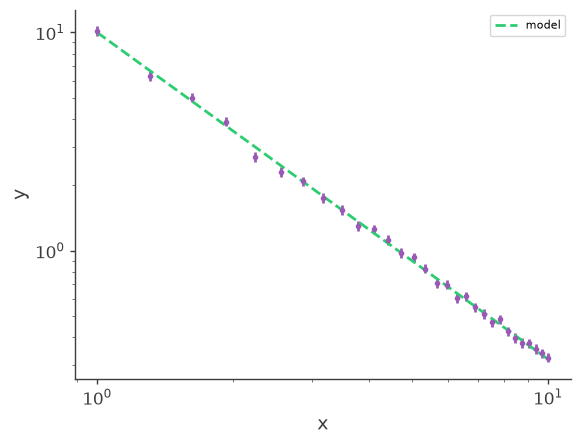

In [9]:
%matplotlib widget
fig = data1.plot(x_scale="log", y_scale="log")

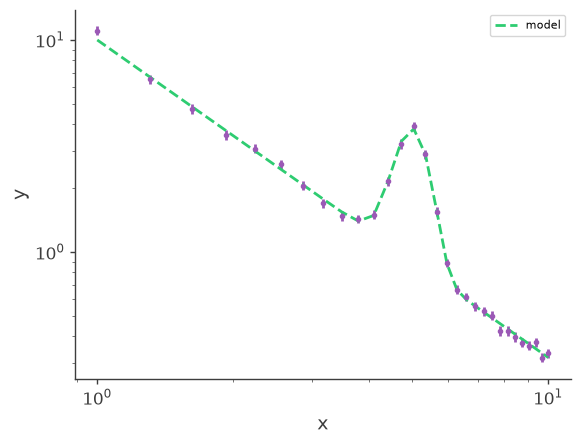

In [10]:
%matplotlib widget
fig2 = data2.plot(x_scale="log", y_scale="log")